Local fetch

In [ ]:
import pandas as pd
import gc
import torch

test_set = pd.read_csv("diversity_sampling/dataset/test.csv")
test_set

DB fetch alternative

In [ ]:
import pandas as pd
import gc
import torch
from diversity_sampling.database.api import get_test_set

test_set = pd.DataFrame(await get_test_set())
test_set

In [ ]:
from diversity_sampling.models import SentimentClassification

classifier = SentimentClassification()

In [ ]:
records = {
    "history": {},
    "results": {}
}

In [ ]:
for i in range(8):
    dataset_name = f"diverse_r_0.{i}0"
    print(dataset_name)
    train_set = pd.read_csv(f"diversity_sampling/dataset/diverse_sampling/{dataset_name}.csv")[['review', 'sentiment']]
    
    for _ in range(3):
        history = classifier.finetune(train_set, batch_size=10, num_epochs=3)    
        results = classifier.predict(test_set)
        # Reser model
        model = classifier.clf.to("cpu")
        del model
        gc.collect()
        torch.cuda.empty_cache()    
        classifier.clf = classifier._load_model(classifier.default_model_id, quantization=False)
        
        
    
        records = {
            "history": history,
            "results": results
        }
    
    torch.save(records, f"diversity_sampling/storage/trained_results/diverse/{dataset_name}.pt")
    print("saved")
    
    

***

# Result graph

In [ ]:
import pandas as pd

# Read results
trained_res = {}
torch.serialization.add_safe_globals(records)
for i in range(5):
    dataset_name = f"random_r_0.{i}0"
    trained_res[dataset_name] = (torch.load(f"diversity_sampling/storage/trained_results/random/{dataset_name}.pt"))

history = {i: val['history'] for i, val in trained_res.items()}
predictions = {i: val['results']['predictions'] for i, val in trained_res.items()}
truth = {i: val['results']['truth'] for i, val in trained_res.items()}
    

Diverse sampling

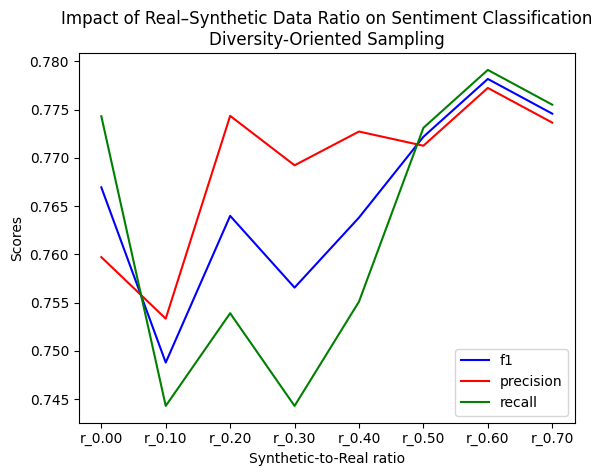

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, recall_score, precision_score
trained_res = {}

for i in range(8):
    dataset_name = f"random_r_0.{i}0"
    trained_res[dataset_name] = (torch.load(f"diversity_sampling/storage/trained_results/diverse/{dataset_name}.pt", weights_only=False))

history = {i: val['history'] for i, val in trained_res.items()}
predictions = {i: val['results']['predictions'] for i, val in trained_res.items()}
truth = {i: val['results']['truth'] for i, val in trained_res.items()}

tags = [x.replace("random_", "") for x in predictions.keys()]
f1_scores = [f1_score(t,p) for t,p in zip(truth.values(), predictions.values())]
precision_scores = [precision_score(t,p) for t,p in zip(truth.values(), predictions.values())]
recall_scores = [recall_score(t,p) for t,p in zip(truth.values(), predictions.values())]

plt.title("Impact of Real–Synthetic Data Ratio on Sentiment Classification\nDiversity-Oriented Sampling")
plt.xlabel("Synthetic-to-Real ratio")
plt.ylabel("Scores")
plt.plot(tags, f1_scores, color='Blue', label="f1",)
plt.plot(tags, precision_scores, color='Red', label="precision")
plt.plot(tags, recall_scores, color='Green', label="recall")
plt.legend()
    

In [ ]:
print([x for x in f1_scores])
print([x for x in precision_scores])
print([x for x in recall_scores])

Random sampling

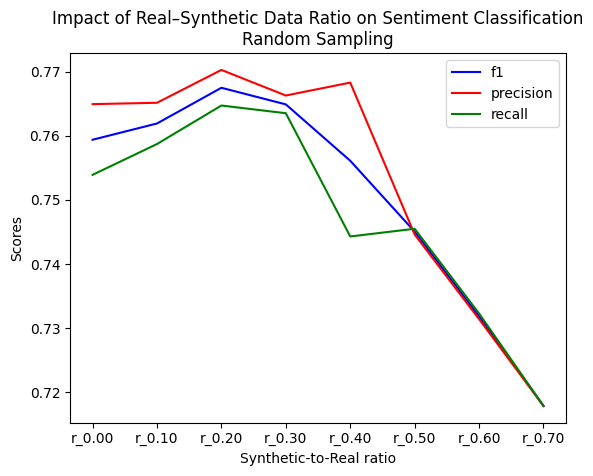

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, recall_score, precision_score
trained_res = {}

for i in range(8):
    dataset_name = f"random_r_0.{i}0"
    trained_res[dataset_name] = (torch.load(f"diversity_sampling/storage/trained_results/random/{dataset_name}.pt", weights_only=False))

history = {i: val['history'] for i, val in trained_res.items()}
predictions = {i: val['results']['predictions'] for i, val in trained_res.items()}
truth = {i: val['results']['truth'] for i, val in trained_res.items()}

tags = [x.replace("random_", "") for x in predictions.keys()]
f1_scores = [f1_score(t,p) for t,p in zip(truth.values(), predictions.values())]
precision_scores = [precision_score(t,p) for t,p in zip(truth.values(), predictions.values())]
recall_scores = [recall_score(t,p) for t,p in zip(truth.values(), predictions.values())]

plt.title("Impact of Real–Synthetic Data Ratio on Sentiment Classification\nRandom Sampling")
plt.xlabel("Synthetic-to-Real ratio")
plt.ylabel("Scores")
plt.plot(tags, f1_scores, color='Blue', label="f1",)
plt.plot(tags, precision_scores, color='Red', label="precision")
plt.plot(tags, recall_scores, color='Green', label="recall")
plt.legend()
    

In [ ]:
print([x for x in f1_scores])
print([x for x in precision_scores])
print([x for x in recall_scores])